In [6]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform, bluenoise
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm
from alter_morph.lattice_utilities import add_contacts
from kwant import kpm
import tinyarray as ta
from scipy import linalg as la
import kwant
from alter_morph.kwant_version import Amorphous

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

from copy import copy
import numpy as np
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375
from time import time

In [19]:
# create koala lattice

lattice = generate_lattice(uniform(10))
lattice = gu.cut_boundaries(lattice)
lattice = gu.remove_trailing_edges(lattice)


In [52]:
def lattice_ham_to_kwant(lattice, hamiltonian):
    n_orbs = hamiltonian.shape[0] // lattice.n_vertices

    syst = kwant.Builder()
    lat_kwant = Amorphous(n_orbs, lattice)

    on_site_terms = [
        hamiltonian[i * n_orbs : (i + 1) * n_orbs, i * n_orbs : (i + 1) * n_orbs]
        for i in range(lattice.n_vertices)
    ]

    for i in range(lattice.n_vertices):
        if np.any(on_site_terms[i]):
            syst[lat_kwant(i)] = on_site_terms[i]

    for i in range(lattice.n_vertices):
        for j in range(i):
            element = hamiltonian[
                i * n_orbs : (i + 1) * n_orbs, j * n_orbs : (j + 1) * n_orbs
            ]
            if np.any(element):
                syst[lat_kwant(i), lat_kwant(j)] = element

    return syst


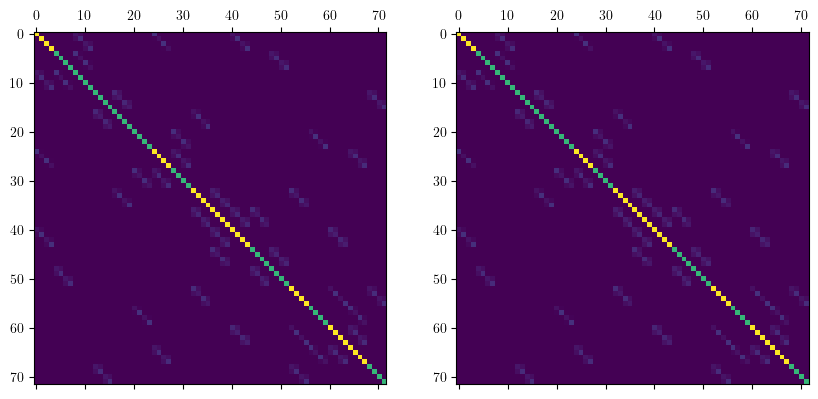

In [53]:
t1 = 1
t2 = 0.3
J = 2
filling = 0.1

lat = lattice
initial_m = np.zeros(lat.n_vertices) + 1.2

ham = alt_hamiltonian(lat, t1, t2, J, initial_m)
ham = ham.astype(complex)

syst = lattice_ham_to_kwant(lat, ham)


syst = syst.finalized()
syst.hamiltonian_submatrix()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].matshow(np.abs(ham))
ax[1].matshow(np.abs(syst.hamiltonian_submatrix()))


assert np.allclose(syst.hamiltonian_submatrix(), ham)


In [10]:
kwant.kpm.SpectralDensity(syst)


True

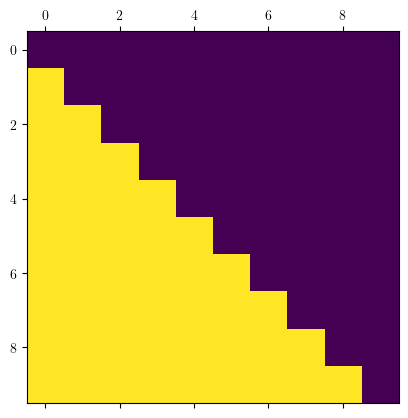

In [ ]:
m1 = np.ones([10, 10])
m2 = np.zeros([10, 10])
for i in range(10):
    for j in range(i):
        m2[i, j] = m1[i, j]
plt.matshow(m2)


np.any([0, 0, 1234, 0])